# A single-band model for La$_{2}$CuO$_{4}$

In this tutorial, we will solve an effective one-band model for La$_{2}$CuO$_{4}$ derived from first-principles within DMFT. Starting from a DFT calculation, we downfolded the full band structure to a minimal correlated subspace using Wannier functions (see [Tutorial 00](00s-dft.ipynb). We include strong local correlations beyond DFT within the single-site dynamical mean-field theory (DMFT) approximation and solve the resulting interacting model self-consistently. While single-site DMFT does not capture all features of cuprate physics (e.g., momentum-dependent self-energies or pseudogap behavior), it provides a foundational framework to understand spectral weight transfer, quasiparticle renormalization, and Mott physics in a realistic setting.

Specifically, you will learn how to:

- Construct and solve the DMFT equations using TRIQS/ModEST
- Analytically continue Matsubara Green's functions
- Post-process and interpret spectral functions and self-energies

## 🧠 1. DMFT loop from scratch

We'll build a single-site DMFT loop for La$_{2}$CuO$_{4}$ using TRIQS/ModEST. We'll proceed in stages, and **your final task will be to write the DMFT self-consistency loop.**

### 🧪 Exercise 1: Load one-body elements
We'll start by loading the target electron density and one-body elements (or obe for short) from the HDF5 file we produced in step 2. Load the ``triqs_modest`` module and use the function ``one_body_elements_from_dft_converter``.

> 💡**Tip**: if you want to see the function signature without leaving the notebook to search the API, you can write
> 
> ```
> ?name_of_function
> ```
> 
> This will produce for you a Docstring for the ``name_of_function``

In [1]:
import bzsummation as modest
?modest.one_body_elements_from_dft_converter

Docstring:
Dispatched C++ function
[1]  (filename: const std::string &, threshold: double, diagonalize_hloc: bool) -> std::pair<double, triqs::modest::one_body_elements_on_grid>

   Parameters
   ----------
   
   filename:
      Hdf5 file from dft_tools converter.
   threshold:
      Off-diagonal threshold for discovery of symmetries.
   diagonalize_hloc:
      Diagonalize the local non-interacting hamiltonian.
   verbosity:
      Log steps of creating the one-body elements.
   
   Returns
   -------
   
   The total electron density and a one-body elements.
Type:      builtin_function_or_method

In [2]:
hdf5_filename = 'data/mlwf/lco_wannier.h5'
target_density, obe = modest.one_body_elements_from_dft_converter(hdf5_filename)
print(obe)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 1
      Represented on a fixed grid of 343 points.
      Shape of H[k_idx, σ, ν, ν'] = [343, 1, 1, 1]
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 1
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   1
             a:   0
        irreps: [1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [343, 1, 1, 1]
  IBZ = false



#### 🔎 Explanation of the OBE

We are studying La$_{2}$CuO$_{4}$ approximated as a single-band system meaning that the low-energy degrees of freedom have been reduced to a single correlated Wannier orbital, the Cu-$d_{x^{2}-y^{2}}$ orbital.

The one-body elements (OBE) class contains four pieces:

##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$
This is the non-interacting (Kohn-Sham) Hamiltonian in Bloch space. $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.

##### 🔹 C_space: Local (correlated) orbital space
This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. It appropriately reflects that we are studying: 1 correlated atom with a single-correlated orbital.

##### 🔹 P: the downfolding projector
For our case, the downfolding projector is a trivial identiy matrix. However, when working with different DFT codes or performing a charge self-consistent DFT+DMFT calculation, the projectors become $k$-dependent.

##### 🔹 IBZ: irreducible Brillouin zone symmetrizer
This indicates that the grid of $k$-points spans the **full Brillouin zone**, not just the irreducible wedge (which requires additional symmetry operations to reconstruct the full observable when performing $k$-summations).

### 🧪 Exercise 2: Embedding Description
Create an embedding description from the local space defined in ``obe.C_space``. A central object in TRIQS/ModEST is the ``Embedding`` class, which describes how to map impurity self-energies back to be embedded back to the lattice. For our simple problem, this is trivial, but for more complicated embedding scenarios this can become quite involved (see tutorial ``04-dp-model``). To create an embedding, you can use the function ``make_embedding_with_equivalences``.

In [3]:
E = modest.make_embedding_with_equivalences(obe.C_space)
print(E)

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1
        α:   0

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  



#### 🔎 Explanation of Embedding

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channesls. Below is a detailed breakdown of the printout from the ``Embedding`` object.

##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]
These are the names of the block-diagonal spin indices $\sigma$ in the lattice model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.

We distinguish between:

- $\sigma$: the spin index in the **embedded lattice problem**, and
- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).

This distinction allows us to support more generic embeddings.

##### 🔹  $\Sigma$_embed block decomposition
This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, 

- ``dim_α = 1``: There is only **one embedding block** (denoted by index $\alpha= 0$) corresponding to one correlated orbital.
- This is a **single-orbital** DMFT problem, so the self-energy is scalar valued for each spin.

##### 🔹  Impurities
This describes the structure of the **impurity problems** constructed from the local space:

- ``n_imp = 0``: There is one impurity solver (index 0).
- For this impurity solver: there is one correlated orbital with dimension 1 (``dim_γ``).
- The impurity Green's function will therefore have **two blocks**: one for spin-up and one for spin-down.

The solver's block structure (``gf_struct``) is printed:
```
[imp_idx = 0] up_0 [1], down_0 [1]
```
This means:
- The impurity solver has **two blocks**, one for each spin, and
- Each block is of dimension 1.

##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 
This table gives the **mappping from the embedded indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.

This means:
- The single correlated orbital in the system is mapped to impurity problem 0.
- The spin-up block maps to the spin-up block of the impurity solver.
- The spin-down block maps to the spin-down block of the impurity solver.

### 🧪 Exercise 3: Chemical Potential and Local Green's function
Let's use a root finder scheme to find the chemical potential and subsequently compute the local non-interacting Green's function. You will use the functions ``find_chemical_potential`` and ``gloc``.

In order to complete this exercise, you will need to define a mesh. We will work at finite-temparature in the imaginary time formalism, so we will compute the local Green's function on the Matsubara axis with inverse temperature $\beta$ = 10 1/eV.

In [4]:
from triqs.gf import MeshImFreq

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

# Step 1: find the chemical potential for target density
mu = modest.find_chemical_potential(target_density, obe, beta, verbosity=True) # verbosity broken!

# Step 2: use this chemical potential to compute the local Green's function.
gloc_C = modest.gloc(mesh, obe, mu)
print(gloc_C)

Green's Function  composed of 2 2-index blocks: 
 Greens Function ('0', 'up') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function ('0', 'down') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 4: Extract the Local Green's function for the impurity solver(s)
The function ``gloc`` returns the local Green's function in the full correlated subspace. In general, this object is of dimension $ M\times M$. To connect to the impurity solver, we would like to view this Green's function in the space of impurity model(s). This is where the ``Embedding`` class comes in. The class contains two methods: ``extract`` and ``embed``.

- ``extract``: maps a Green's function (or array) from the full correlated space to the space of each impurity solver.
- ``embed``: (reverse of extract) maps a list of Green's functions (or arrays) and embeds these impurities into the bigger correlated space according to the mapping described in the ``Embedding``.

Thus, to prepare the Green's function for the impurity solver, we will use the ``extract`` method from the ``Embedding`` class. In general, the extract function will return a list of objects where the length corresponds to the number of impurity problems defined in the embedding description. Because we are working with a single impurity, we will simply grab the first element from this list everytime this function is called.

> 💡 **Note**: for a more complicated multi-site, multi-orbital DMFT problem, it is often convenient to loop over these lists.

In [5]:
Gloc = E.extract(gloc_C)[0]
print(Gloc)

Green Function G composed of 2 blocks: 
 Greens Function G_up_0 with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function G_down_0 with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 5: Impurity Levels and Hybridization function

The central inputs to the impurity solver are the impurity levels ($\varepsilon_{d}$) and the hybridization function ($\Delta(i\omega_{n})$). In this excercise, you will calculate the impurity levels and the hybridization function. The impurity levels correspond to:

$$ [\varepsilon_{d}]_{m m'} = \sum_{k} P_{m\nu}(k) (H_{\nu\nu'}(k)-\mu) P^{\dagger}_{m'\nu'},$$
where $\mu$ is the chemical potential. We can compute the impurity levels with the function ``impurity_levels`` which takes as an argument the ``obe``.

> 💡 **Tip**: The function ``impurity_levels`` returns the local impurity levels in the full correlated space. In a similar fashion to the local Green's function, you can use ``Embedding``'s ``extract`` function to obtain the impurity levels for each impurity problem.

The hybridization function is defined as:

$$ \Delta(\omega) = \omega - \varepsilon_{d} - \mathcal{G}_{0}^{-1}(\omega), $$

where $\mathcal{G}_{0} = ((G_{\text{loc}})^{-1} + \Sigma)^{-1}$. The hybridization function can be computed using the function ``extract_delta``.

In [6]:
# Step 1: impurity levels in the C space
hloc0_C = modest.impurity_levels(obe) - mu

# Step 2: extract the local levels into the impurity space
hloc0 = E.extract(hloc0_C)[0]

# Step 3: compute Δ using mu, hloc0 and Gloc
Delta_iw = modest.extract_delta(hloc0, Gloc)

### 🧪 Exercise 6: Define the interaction
We need to define the interaction Hamiltonian for our impurity model. For our model, this is:

$$ H_{\text{int}} = U n^{\uparrow} n^{\downarrow}.$$

Use the many-body operators within the TRIQS library to write this interaction. Let's take $U$ = 3.6 eV.

> 💡 **Tip**: The many-body operators must match between all of your Green's functions. You can always get the operator names from the member ``imp_block_shapes`` from the ``Embedding`` class. For our example, the fundamental operators are ``c('up_0',0)`` and ``c('down_0', 0)``.

In [9]:
from triqs.operators import n
from common import solve

U = 3.6
h_int = U*n('up_0',0)*n('down_0',0)

Starting serial run at: 2025-07-23 10:29:08.178196


### ▶️ Run the CT-HYB impurity solver

In [15]:
solver_params = dict(length_cycle=60, n_cycles = int(2e+6), 
                          n_warmup_cycles = int(1e+5),
                          perform_tail_fit=True, fit_min_w=10, fit_max_w=14,
                          imag_threshold = 1e-6)
results = solve(Delta_iw, hloc0, h_int, **solver_params)


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
0.0983631*c_dag('down_0',0)*c('down_0',0) + 0.0983631*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:34:15   1% ETA 00:00:05 cycle 1653 of 100000
10:34:17  43% ETA 00:00:02 cycle 43985 of 100000
10:34:20  97% ETA 00:00:00 cycle 97052 of 100000
10:34:20 100% ETA 00:00:00 cycle 99999 of 100000



Accumulating ...
10:34:20   0% ETA 00:01:38 cycle 2037 of 2000000
10:34:22   2% ETA 00:01:36 cycle 42968 of 2000000
10:34:24   4% ETA 00:01:34 cycle 93785 of 2000000
10:34:28   7% ETA 00:01:31 cycle 157208 of 2000000
10:34:31  11% ETA 00:01:27 cycle 236940 of 2000000
10:34:36  16% ETA 00:01:22 cycle 336466 of 2000000
10:34:43  22% ETA 00:01:16 cycle 459265 of 2000000
10:34:50  30% ETA 00:01:09 cycle 613540 of 200

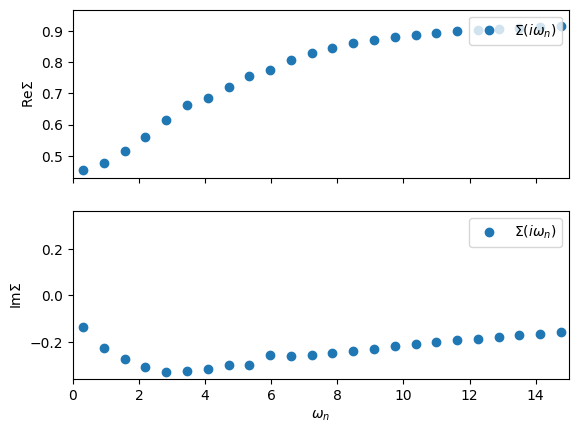

In [14]:
from triqs.plot.mpl_interface import oplot, plt

fig, ax = plt.subplots(2,1, sharex=True)
ax[0].oplot(results.Sigma_iw['up_0'].real, 'o', label=r'$\Sigma(i\omega_{n})$'); 
ax[0].set_ylabel(r'Re$\Sigma$'); ax[0].set_xlabel('')
ax[1].oplot(results.Sigma_iw['up_0'].imag, 'o', label=r'$\Sigma(i\omega_{n})$'); 
ax[1].set_ylabel(r'Im$\Sigma$')
ax[0].set_xlim(0, 15)
plt.show()

### 🧪 Exercise 7: Write the DMFT update in a loop

You now have all of the pieces to write the DMFT self-consistencey loop. Your task is to fill in the steps that occur during each DMFT iteration, such as solving the impurity problem, updating the self-energy, chemical potential, Green's function, and hybridization function.

#### 🧩 Your Task
Fill in the provided pseudocode to perform the following steps for each DMFT iteration:
1. Solve the impurity problem
2. Embed the self-energy
3. Update the chemical potential
4. Compute the local Green's function
5. Update the hybridization function

In [16]:
n_dmft_loops = 10
delta_n=[]

for n_iter in range(n_dmft_loops):
    print(f"DMFT iteration= {n_iter}")
    
    # solve!
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)
    
    # update Sigma!
    Sigma_dynamic_C  = E.embed([ solver_results.Sigma_dynamic ])
    Sigma_hartree_C  = E.embed([ solver_results.Sigma_Hartree ])

    # update mu!
    mu     = modest.find_chemical_potential(target_density, obe, Sigma_dynamic_C, Sigma_hartree_C, verbosity=False)
    
    # update Gloc!
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_dynamic_C, Sigma_hartree_C))[0]

    # update hloc0 with μ!
    hloc0 = E.extract(modest.impurity_levels(obe) - mu)[0]
    
    # update Δ!
    Delta_iw = modest.extract_delta(hloc0, Gloc, solver_results.Sigma_dynamic, solver_results.Sigma_Hartree)
    
    delta_n.append(abs(Gloc.total_density()-solver_results.G_iw.total_density()))
    print(f"Δn = |n_lattice - n_impurity| = {delta_n[-1]}")

DMFT iteration= 0

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
0.0983631*c_dag('down_0',0)*c('down_0',0) + 0.0983631*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:36:41   1% ETA 00:00:06 cycle 1624 of 100000
10:36:43  43% ETA 00:00:02 cycle 43246 of 100000
10:36:46  94% ETA 00:00:00 cycle 94540 of 100000
10:36:46 100% ETA 00:00:00 cycle 99999 of 100000



Accumulating ...
10:36:46   0% ETA 00:01:38 cycle 2019 of 2000000
10:36:48   2% ETA 00:01:39 cycle 41704 of 2000000
10:36:51   4% ETA 00:01:37 cycle 90992 of 2000000
10:36:54   7% ETA 00:01:35 cycle 151244 of 2000000
10:36:58  11% ETA 00:01:30 cycle 230455 of 2000000
10:37:03  16% ETA 00:01:25 cycle 327411 of 2000000
10:37:09  22% ETA 00:01:19 cycle 446714 of 2000000
10:37:17  29% ETA 00:01:12 c

Execution time: 

Δn = |n_lattice - n_impurity| = 0.47848122833769635
DMFT iteration= 1

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-0.471232*c_dag('down_0',0)*c('down_0',0) + -0.471232*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:38:35   2% ETA 00:00:04 cycle 2049 of 100000
10:38:37  43% ETA 00:00:02 cycle 43879 of 100000
10:38:40  96% ETA 00:00:00 cycle 96158 of 100000
10:38:40 100% ETA 00:00:00 cycle 99999 of 100000



Accumulating ...
10:38:40   0% ETA 00:01:38 cycle 2029 of 2000000
10:38:42   2% ETA 00:01:36 cycle 43138 of 2000000
10:38:44   4% ETA 00:01:33 cycle 94755 of 2000000
10:38:48   7% ETA 00:01:30 cycle 159008 of 2000000
10:38:51  11% ETA 00:01:26 cycle 239023 of 2000000
10:38:56  17% ETA 00:01:21 cycle 340451 of 2000000
10:39:03  23% ETA 00:01:15 

0.132465 seconds
Execution time: 0.134534 seconds


Δn = |n_lattice - n_impurity| = 0.14409522414721632
DMFT iteration= 3

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.11291*c_dag('down_0',0)*c('down_0',0) + -1.11291*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:42:05   2% ETA 00:00:04 cycle 2427 of 100000
10:42:07  51% ETA 00:00:01 cycle 51744 of 100000
10:42:09 100% ETA 00:00:00 cycle 99999 of 100000



Accumulating ...
10:42:09   0% ETA 00:01:23 cycle 2395 of 2000000
10:42:11   2% ETA 00:01:20 cycle 51234 of 2000000
10:42:13   5% ETA 00:01:18 cycle 112293 of 2000000
10:42:16   9% ETA 00:01:15 cycle 187594 of 2000000
10:42:20  14% ETA 00:01:12 cycle 280415 of 2000000
10:42:25  19% ETA 00:01:07 cycle 396282 of 2000000
10:42:31  27% ETA 00:01:01 cycle 541320 of 2000000
10:42:39  35% ETA 00:00:54

...

IOStream.flush timed out
Execution time: 0.138605 seconds
Insert error : recovering ... 


Δn = |n_lattice - n_impurity| = 0.022768474221685153
DMFT iteration= 8

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.61909*c_dag('down_0',0)*c('down_0',0) + -1.61909*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:49:29   2% ETA 00:00:03 cycle 2734 of 100000
10:49:31  58% ETA 00:00:01 cycle 58907 of 100000
10:49:32 100% ETA 00:00:00 cycle 99999 of 100000



Accumulating ...
10:49:32   0% ETA 00:01:14 cycle 2674 of 2000000
10:49:34   2% ETA 00:01:11 cycle 57562 of 2000000
10:49:37   6% ETA 00:01:08 cycle 126454 of 2000000
10:49:40  10% ETA 00:01:05 cycle 213385 of 2000000
10:49:44  16% ETA 00:01:01 cycle 323336 of 2000000
10:49:49  22% ETA 00:00:55 cycle 459839 of 2000000
10:49:55  31% ETA 00:00:49 cycle 632464 of 2000000
10:50:03  42% ETA 00:00:4

Execution time: 0.132631 seconds
Insert error : recovering ... 
Execution time: 0.1321 seconds
Insert error : recovering ... 


Δn = |n_lattice - n_impurity| = 0.01945017039167707
DMFT iteration= 9

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.66499*c_dag('down_0',0)*c('down_0',0) + -1.66499*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:50:51   2% ETA 00:00:03 cycle 2840 of 100000
10:50:53  61% ETA 00:00:01 cycle 61367 of 100000
10:50:54 100% ETA 00:00:00 cycle 99999 of 100000



Accumulating ...
10:50:55   0% ETA 00:01:12 cycle 2738 of 2000000
10:50:57   2% ETA 00:01:10 cycle 58887 of 2000000
10:50:59   6% ETA 00:01:08 cycle 127531 of 2000000
10:51:02  10% ETA 00:01:05 cycle 213467 of 2000000
10:51:06  16% ETA 00:01:01 cycle 322755 of 2000000
10:51:11  22% ETA 00:00:56 cycle 457936 of 2000000
10:51:17  31% ETA 00:00:50 cycle 627065 of 2000000
10:51:25  41% ETA 00:00:42

Execution time: 0.130599 seconds


In [ ]:
fig, ax = plt.subplots(figsize=(5,1))
ax.semilogy(delta_n, 'o-')

fig, ax = plt.subplots(2,2,sharex=True)
ax[0,0].oplot(solver_results.Sigma_iw['up_0'].real, 'o-', label=r'Re$\Sigma$')
ax[0,1].oplot(solver_results.Sigma_iw['up_0'].imag, 'o-', label=r'Im$\Sigma$')
ax[0,0].set_xlim(0, 20)

ax[1,0].oplot(solver_results.G_iw['up_0'].real, 'o-', label=r'Re$G$')
ax[1,1].oplot(solver_results.G_iw['up_0'].imag, 'o-', label=r'Im$G$')

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

### 🧪 Exercise 8: Estimate Z from the Matsubara self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = (1 - \partial_{\omega_{n}}\text{Im}\Sigma(i\omega_{n}) |_{\omega_{n}\rightarrow0})^{-1}.$$

## 🌀 2. Analytic continuation: from Matsubara to real frequencies

In this section, we will learn how to **analytically continue** our results from Matsubara (imaginary) frequencies onto the real-frequency axis, so that we may plot spectral functions. Because analytic continuation is an ill-posed problem, it is notoriously unstable, and the method itself remains an active area of research. However, there are two common analytic continuation techniques: Padé analytic continuation and the maximum entropy (MaxEnt) method. In this section, we will use Padé analytic contintuation since it is simpler. There is an additional tutorial using the MaxEnt method to continue the data.

### ❓The problem
We assume the Matsubra Green's function $G(i\omega_{n})$ corresponds to a dynamic correlation function $G(\omega)$ where $\omega_{n}$ is the Matsubara frequency and $\omega$ is the real frequency. The function $G(z)$ is analytic in the whole upper complex plane of $z$ excluding the real axis, the retarded Green function can be obtained by analytic contintuation $$G(\omega) = G(i\omega_{n}\rightarrow \omega + i0^{+})$$. The spectral function $A(\omega)$ is determined by taking the imaginary part of $G(\omega + i0^{+})$ by the formula

$$ A(\omega) = -\frac{1}{\pi}\mathrm{Im}G(\omega + i0^{+})$$

### 📐 Padé method
Padé analytic continuation is based on the assumption that the Matsubara Green function can be approximated by a rational function of degree $r$

$$ G(z) = \frac{\sum_{i=0}^{r-1} p_{i}z^{i}}{\sum_{j=0}^{r-1}q_{j}z^{j} + z^{r}}, $$
where $p_{i}$ and $q_{j}$ are complex. The coefficients can be determined by solving $2r$ linear equatiions from $2r$ arbitrary but different input points ${i\omega_{n}, G(i\omega_{n})}$. Once the coefficients are determined, we replace $z$ with $\omega + i0^{+}$ to obtain the retarded correlation function.

### 🧪 Exercise 6: Analytically continue the Matsubara Green's function

In this exercise, we will analytically continue the Matsubara Green's function onto the real frequency axis.

#### 🧩 Your task
1. set up a ``BlockGf`` with a real frequency mesh ``MeshReFreq``.
2. For each block in the Matsubara Green's function, use the ``set_from_pade`` method to obtain the real frequency Green's function for each block.
3. Plot the resulting spectral function using the formula $A(\omega) = -\frac{1}{\pi}\text{Im}G(\omega + i0^{+})$.

In [ ]:
from triqs.gf import BlockGf, MeshReFreq

n_w = 1000
window = (-10, 10)

# Step 1: set up real-frequency mesh and BlockGf

## get the block shape of the Matsubara Green's function
gf_struct = [ (bl, g.target_shape[0]) for bl, g in solver_results.G_iw ]

## setup real-frequency mesh
mesh = MeshReFreq(window, n_w)

## construct Block Green's function on real-frequency mesh
G_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 21
freq_offset = 0.0
for block, g in G_w: 
    g.set_from_pade(solver_results.G_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(figsize=(5,3))
ax.oplot(-1/np.pi*G_w.imag, lw=1)
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 1)
plt.show()

In [ ]:
from triqs_maxent import PoormanMaxEnt, LogAlphaMesh, HyperbolicOmegaMesh
maxent_anacont = {}
for block, g in solver_results.G_tau:
    tm = PoormanMaxEnt(use_complex=True)
    tm.set_G_tau(solver_results.G_tau[block])
    tm.alpha_mesh = LogAlphaMesh(alpha_min=1e-6, alpha_max=1e2, n_points=50)
    tm.omega = HyperbolicOmegaMesh(omega_min=-10, omega_max=10, n_points=200)
    tm.set_error(0.04)
    maxent_anacont[block] = tm.run()

### 🧪 Exercise 7: Analytically continue the Matsubara self-energy

In this exercise, we will analytically continue the Matsubara self-energy onto the real-frequency axis. Due to implementation details, you can directly use the same Python code to analytically continue a self-energy in the same way as a Green's function in TRIQS. 

In [ ]:
n_w = 1000
window = (-10, 10)

# Step 1: construct Block Green's function on real-frequency mesh
Sigma_w_pade = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 17
freq_offset = 0.0
for block, g in Sigma_w_pade: g.set_from_pade(solver_results.Sigma_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(2,1,sharex=True, figsize=(5,4))
ax[0].oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, mode='R', lw=1, label='Re')
ax[1].oplot(-Sigma_w_pade['up_0'], mode='I', lw=1, label='Im')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-3,3); ax[1].set_ylim(0, ); 
ax[0].set_xlabel('')
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.show()

In [ ]:
from triqs_maxent import InversionSigmaContinuator

n_w = 1000
window = (-10, 10)
Sigma_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

omega = HyperbolicOmegaMesh(omega_min=-10, omega_max=10, n_points=200)
inversion_sigma_continuator = InversionSigmaContinuator(solver_results.Sigma_iw, solver_results.Sigma_Hartree._data)
maxent_results = {}
for block, gaux in inversion_sigma_continuator.Gaux_iw:
    tm = PoormanMaxEnt(use_complex=True)
    tm.set_G_iw(gaux)
    tm.alpha_mesh = LogAlphaMesh(alpha_min=1e-6, alpha_max=1e2, n_points=50)
    tm.omega = omega
    tm.set_error(0.04)
    maxent_results[block] = tm.run()

Aux_w = { block : result.get_A_out('LineFitAnalyzer') for block, result in maxent_results.items() }
inversion_sigma_continuator.set_Gaux_w_from_Aaux_w(Aux_w, omega, np_interp_A=10000, np_omega=n_w, w_min=window[0], w_max=window[1])

Sigma_w = inversion_sigma_continuator.S_w

In [ ]:
fig, ax = plt.subplots(figsize=(5,3))
for (block, result) in maxent_anacont.items():
    ax.plot(result.omega, result.analyzer_results[0][0][0]['LineFitAnalyzer']['A_out'], label=f'MaxEnt+{block}')
    ax.oplot(-1/np.pi*G_w[block].imag, lw=1, label=f'Padé+{block}')
ax.set_xlim(-5,5); ax.set_ylim(0, 0.7); ax.legend(frameon=False,ncols=2,bbox_to_anchor=(0.5,1.25), loc='upper center');
ax.set_ylabel(r'$A(\omega)$'); plt.show()

In [ ]:
fig, ax = plt.subplots(2,1,sharex=True, figsize=(5,4))
ax[0].oplot(Sigma_w['up_0']-Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1, label='MaxEnt')
ax[1].oplot(-Sigma_w['up_0'], mode='I', lw=1, label='MaxEnt')
ax[0].oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, mode='R', lw=1, label='Pade')
ax[1].oplot(-Sigma_w_pade['up_0'], mode='I', lw=1, label='Pade')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-3,3); ax[1].set_ylim(0, ); 
ax[0].set_xlabel('')
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.show()

### 🧪 Exercise 8: Estimate Z and the scattering rate from the self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = (1 - \partial_{\omega}\text{Re}\Sigma(\omega) |_{\omega\rightarrow0})^{-1}.$$
The scattering rate $\Gamma$ is proportional to $-\mathrm{Im}\Sigma(\omega=0)$. For $Z$, you can fit a linear line to the low-frequency data in the real part of spectrum and use the slope of the line to estimate the derivate.  For the scattering rate, you can fit a polynomial to the low-frequency data in the imaginary part of the self-energy and estimate $-\text{Im}\Sigma(0)$ from this fit.

In [ ]:
x = np.linspace(-0.2, 0.2,10)
y = [Sigma_w['up_0'][0,0](xx).real for xx in x]
dSdw = np.polyfit(x,y,1)[0]
Z = 1/(1 - dSdw)
print(f'     Z  =  {Z}')
print(f'-ImΣ(0) = {Sigma_w['up_0'][0,0](0.0).imag}')

## 📊 3. Plotting our results

### 🧪 Exercise 9: Plot the momentum-resolved spectral function along the high-symmetry path in the Brillouin zone

In [ ]:
from triqs.lattice.utils import TB_from_wannier90, k_space_path
tb = TB_from_wannier90(seed='lco', path = './data/mlwf/')

G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments, bz=tb.bz)

ek = tb.dispersion(k_points)

Akw = momentum_resolved_spectral_function(ek, mu, Sigma_w['up_0'], broadening=0.01)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot_spectral_function(Akw, k_lin, k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'], cmap='Purples', vmin=0, vmax=np.max(Akw))
ax2 = ax.twiny();
ax2.plot_bands(w90_kpts, w90_bands-eF, lw=1, color='green')
ax2.set_xlim(min(w90_kpts), max(w90_kpts)); ax2.set_xticks([])
ax.set_ylim(-4,4)
plt.show()

### 🧪 Exercise 10: Describe your results
In a few words, describe your spectral function results for both $A(\omega)$ and $A(k, \omega)$. Compare the interacting spectrum to the non-interacting. Can you connect any of these changes to features in the self-energy?

Band renormalization ($Z$) and upper and lower Hubbard bands at $U/2$.

### 🧪 Exercise 11: Plot the Fermi surface

In [ ]:
# TODO: plot the Fermi surface 